In [1]:
!pip install -q tensorflow tensorflow-quantum scikit-learn cirq seaborn sympy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 597.5/597.5 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.1/425.1 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.7/323.7 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.6/615.6 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.1/105.1 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 33.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take

## QGAN-Inspired Quantum Classifier

In [2]:
import sys
import os
import numpy as np
import cirq
import sympy
import tensorflow as tf

try:
    import tensorflow_quantum as tfq
    TFQ_AVAILABLE = True
except ImportError:
    TFQ_AVAILABLE = False
    print("WARNING: TensorFlow Quantum not available. Using simulation mode.")

from typing import List, Tuple, Optional, Dict, Any
from dataclasses import dataclass
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report
import json

In [3]:
# Keras 3 Compatible PQC Layer

class Keras3PQC(tf.keras.layers.Layer):
    """Keras 3 compatible PQC layer wrapper.

    This layer wraps TFQ's expectation calculation to be compatible with Keras 3's
    add_weight API changes. It appends a parameterized circuit to input circuits
    and computes expectation values.
    """

    def __init__(self, model_circuit, operators, symbol_names, **kwargs):
        super().__init__(**kwargs)
        self.model_circuit = model_circuit
        self.operators = operators
        self.symbol_names = symbol_names
        self._num_symbols = len(symbol_names)
        # Convert circuit to tensor for appending
        self._model_circuit_tensor = tfq.convert_to_tensor([model_circuit])
        # Create append layer
        self._append_layer = tfq.layers.AddCircuit()

    def build(self, input_shape):
        # Use Keras 3 compatible add_weight signature
        self.symbol_values = self.add_weight(
            name='symbol_values',
            shape=(self._num_symbols,),
            initializer=tf.keras.initializers.RandomUniform(-np.pi, np.pi),
            trainable=True,
            dtype=tf.float32
        )
        super().build(input_shape)

    def call(self, inputs):
        # Get batch size and tile model circuit to match
        batch_size = tf.shape(inputs)[0]
        tiled_circuits = tf.tile(self._model_circuit_tensor, [batch_size])

        # Append the variational circuit to each input (data encoding) circuit
        appended_circuits = self._append_layer(
            inputs,
            append=tiled_circuits
        )

        # Batch the symbol values for all inputs
        batch_symbols = tf.tile(
            tf.expand_dims(self.symbol_values, 0),
            [batch_size, 1]
        )

        # Use TFQ's expectation layer
        expectation_layer = tfq.layers.Expectation()
        return expectation_layer(
            appended_circuits,
            symbol_names=self.symbol_names,
            symbol_values=batch_symbols,
            operators=self.operators
        )

In [4]:
# Configuration
@dataclass
class QGANConfig:
    """Configuration for the QGAN Classifier."""
    n_qubits: int = 5
    n_layers: int = 2
    encoding_type: str = 'angle'  # 'angle', 'angle_rz', 'iqp'
    entanglement: str = 'linear'  # 'none', 'linear', 'circular', 'full'
    learning_rate: float = 0.05
    batch_size: int = 16
    epochs: int = 100
    validation_split: float = 0.2
    early_stopping_patience: int = 15

    def to_dict(self) -> Dict[str, Any]:
        return {
            'n_qubits': self.n_qubits,
            'n_layers': self.n_layers,
            'encoding_type': self.encoding_type,
            'entanglement': self.entanglement,
            'learning_rate': self.learning_rate,
            'batch_size': self.batch_size,
            'epochs': self.epochs,
            'validation_split': self.validation_split,
            'early_stopping_patience': self.early_stopping_patience
        }


In [5]:
# Data Loading Module

class HEPDataLoader:
    """Load and preprocess HEP event data from NPZ file."""

    def __init__(self, filepath: str):
        self.filepath = filepath
        self.train_data = None
        self.test_data = None

    def load(self) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Load data and return X_train, y_train, X_test, y_test."""
        data = np.load(self.filepath, allow_pickle=True)

        # Extract training data
        train_dict = data['training_input'].item()
        X_train_bg = train_dict['0']
        X_train_sig = train_dict['1']
        X_train = np.vstack([X_train_bg, X_train_sig])
        y_train = np.concatenate([
            np.zeros(X_train_bg.shape[0]),
            np.ones(X_train_sig.shape[0])
        ])

        # Extract test data
        test_dict = data['test_input'].item()
        X_test_bg = test_dict['0']
        X_test_sig = test_dict['1']
        X_test = np.vstack([X_test_bg, X_test_sig])
        y_test = np.concatenate([
            np.zeros(X_test_bg.shape[0]),
            np.ones(X_test_sig.shape[0])
        ])

        # Shuffle training data
        train_idx = np.random.permutation(len(y_train))
        X_train, y_train = X_train[train_idx], y_train[train_idx]

        # Shuffle test data
        test_idx = np.random.permutation(len(y_test))
        X_test, y_test = X_test[test_idx], y_test[test_idx]

        self.train_data = (X_train, y_train)
        self.test_data = (X_test, y_test)

        return X_train, y_train, X_test, y_test

    def get_statistics(self) -> Dict[str, Any]:
        """Get dataset statistics."""
        if self.train_data is None:
            self.load()

        X_train, y_train = self.train_data
        X_test, y_test = self.test_data

        return {
            'n_train': len(y_train),
            'n_test': len(y_test),
            'n_features': X_train.shape[1],
            'train_class_dist': {
                'background': int(np.sum(y_train == 0)),
                'signal': int(np.sum(y_train == 1))
            },
            'test_class_dist': {
                'background': int(np.sum(y_test == 0)),
                'signal': int(np.sum(y_test == 1))
            },
            'feature_ranges': {
                'min': float(X_train.min()),
                'max': float(X_train.max())
            }
        }

In [6]:
# Quantum Circuit Module

class QuantumCircuitBuilder:
    """Build parameterized quantum circuits for classification."""

    def __init__(self, config: QGANConfig):
        self.config = config
        self.qubits = cirq.GridQubit.rect(1, config.n_qubits)
        self.symbols = None

    def _angle_encoding(self, data_symbols: List[sympy.Symbol]) -> cirq.Circuit:
        """Create angle encoding circuit using RY gates."""
        circuit = cirq.Circuit()
        for i, qubit in enumerate(self.qubits):
            circuit.append(cirq.ry(np.pi * data_symbols[i])(qubit))
        return circuit

    def _angle_rz_encoding(self, data_symbols: List[sympy.Symbol]) -> cirq.Circuit:
        """Create enhanced angle encoding with RY + RZ gates."""
        circuit = cirq.Circuit()
        for i, qubit in enumerate(self.qubits):
            circuit.append(cirq.ry(np.pi * data_symbols[i])(qubit))
            circuit.append(cirq.rz(np.pi * data_symbols[i])(qubit))
        return circuit

    def _iqp_encoding(self, data_symbols: List[sympy.Symbol]) -> cirq.Circuit:
        """Create IQP-style encoding with interactions."""
        circuit = cirq.Circuit()
        # Hadamard layer
        for qubit in self.qubits:
            circuit.append(cirq.H(qubit))
        # Z rotations
        for i, qubit in enumerate(self.qubits):
            circuit.append(cirq.rz(np.pi * data_symbols[i])(qubit))
        # ZZ interactions
        for i in range(len(self.qubits) - 1):
            circuit.append(cirq.ZZ(self.qubits[i], self.qubits[i+1])**(
                data_symbols[i] * data_symbols[i+1] / np.pi
            ))
        return circuit

    def _variational_layer(self, layer_symbols: List[sympy.Symbol], layer_idx: int) -> cirq.Circuit:
        """Create a single variational layer."""
        circuit = cirq.Circuit()
        n = self.config.n_qubits

        # Single-qubit rotations: RY and RZ for each qubit
        for i, qubit in enumerate(self.qubits):
            circuit.append(cirq.ry(layer_symbols[2*i])(qubit))
            circuit.append(cirq.rz(layer_symbols[2*i + 1])(qubit))

        # Entangling gates based on configuration
        if self.config.entanglement == 'linear':
            for i in range(n - 1):
                circuit.append(cirq.CNOT(self.qubits[i], self.qubits[i+1]))
        elif self.config.entanglement == 'circular':
            for i in range(n):
                circuit.append(cirq.CNOT(self.qubits[i], self.qubits[(i+1) % n]))
        elif self.config.entanglement == 'full':
            for i in range(n):
                for j in range(i+1, n):
                    circuit.append(cirq.CNOT(self.qubits[i], self.qubits[j]))
        # 'none' - no entanglement

        return circuit

    def build_encoding_circuit(self) -> Tuple[cirq.Circuit, List[sympy.Symbol]]:
        """Build the data encoding circuit."""
        data_symbols = [sympy.Symbol(f'x_{i}') for i in range(self.config.n_qubits)]

        if self.config.encoding_type == 'angle':
            circuit = self._angle_encoding(data_symbols)
        elif self.config.encoding_type == 'angle_rz':
            circuit = self._angle_rz_encoding(data_symbols)
        elif self.config.encoding_type == 'iqp':
            circuit = self._iqp_encoding(data_symbols)
        else:
            raise ValueError(f"Unknown encoding type: {self.config.encoding_type}")

        return circuit, data_symbols

    def build_variational_circuit(self) -> Tuple[cirq.Circuit, List[sympy.Symbol]]:
        """Build the variational (trainable) circuit."""
        all_symbols = []
        circuit = cirq.Circuit()

        params_per_layer = 2 * self.config.n_qubits  # RY + RZ for each qubit

        for layer in range(self.config.n_layers):
            layer_symbols = [
                sympy.Symbol(f'theta_{layer}_{i}')
                for i in range(params_per_layer)
            ]
            all_symbols.extend(layer_symbols)
            circuit += self._variational_layer(layer_symbols, layer)

        self.symbols = all_symbols
        return circuit, all_symbols

    def build_full_circuit(self) -> Tuple[cirq.Circuit, List[sympy.Symbol], List[sympy.Symbol]]:
        """Build complete circuit: encoding + variational."""
        encoding_circuit, data_symbols = self.build_encoding_circuit()
        variational_circuit, var_symbols = self.build_variational_circuit()

        full_circuit = encoding_circuit + variational_circuit
        return full_circuit, data_symbols, var_symbols

    def get_readout_operators(self) -> List[cirq.PauliString]:
        """Get measurement operators."""
        # Measure Z expectation on first qubit
        return [cirq.Z(self.qubits[0])]

    def print_circuit_info(self):
        """Print circuit information."""
        _, data_sym, var_sym = self.build_full_circuit()
        print(f"Circuit Configuration:")
        print(f"  - Qubits: {self.config.n_qubits}")
        print(f"  - Encoding: {self.config.encoding_type}")
        print(f"  - Variational Layers: {self.config.n_layers}")
        print(f"  - Entanglement: {self.config.entanglement}")
        print(f"  - Data parameters: {len(data_sym)}")
        print(f"  - Trainable parameters: {len(var_sym)}")


In [7]:
# Data Encoding for TFQ

class QuantumDataEncoder:
    """Encode classical data into quantum circuits for TFQ."""

    def __init__(self, circuit_builder: QuantumCircuitBuilder):
        self.circuit_builder = circuit_builder
        self.encoding_circuit, self.data_symbols = circuit_builder.build_encoding_circuit()

    def encode_data_point(self, x: np.ndarray) -> cirq.Circuit:
        """Encode a single data point into a quantum circuit."""
        resolver = {self.data_symbols[i]: x[i] for i in range(len(x))}
        return cirq.resolve_parameters(self.encoding_circuit, resolver)

    def encode_batch(self, X: np.ndarray) -> List[cirq.Circuit]:
        """Encode a batch of data points."""
        return [self.encode_data_point(x) for x in X]

    def encode_to_tfq_tensor(self, X: np.ndarray) -> tf.Tensor:
        """Encode data and convert to TFQ tensor."""
        if not TFQ_AVAILABLE:
            raise RuntimeError("TensorFlow Quantum is required for this operation")
        circuits = self.encode_batch(X)
        return tfq.convert_to_tensor(circuits)

In [8]:
# Model Building

class QGANClassifier:
    """Main QGAN-inspired quantum classifier."""

    def __init__(self, config: QGANConfig):
        self.config = config
        self.circuit_builder = QuantumCircuitBuilder(config)
        self.encoder = QuantumDataEncoder(self.circuit_builder)
        self.model = None
        self.history = None

    def build_model(self) -> tf.keras.Model:
        """Build the Keras model with TFQ layers."""
        if not TFQ_AVAILABLE:
            raise RuntimeError("TensorFlow Quantum is required")

        # Build variational circuit
        var_circuit, var_symbols = self.circuit_builder.build_variational_circuit()
        readout_ops = self.circuit_builder.get_readout_operators()

        # Get symbol names as strings for TFQ
        symbol_names = [str(s) for s in var_symbols]

        # Build model using Keras 3 compatible PQC wrapper
        # The quantum layer outputs expectation values in [-1, 1]
        # We add hidden layers to learn the optimal mapping to classification
        model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(), dtype=tf.string),
            Keras3PQC(var_circuit, readout_ops, symbol_names),
            # Rescale from [-1, 1] to [0, 1] for better gradient flow
            tf.keras.layers.Lambda(lambda x: (x + 1) / 2),
            # Add hidden layer for more expressive power
            tf.keras.layers.Dense(8, activation='relu'),
            tf.keras.layers.Dense(1, activation='sigmoid')
        ])

        # Compile
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=self.config.learning_rate),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        self.model = model
        return model

    def prepare_data(self, X: np.ndarray, y: np.ndarray) -> Tuple[tf.Tensor, np.ndarray]:
        """Prepare data for training."""
        X_encoded = self.encoder.encode_to_tfq_tensor(X)
        y = y.astype(np.float32)
        return X_encoded, y

    def train(self, X_train: np.ndarray, y_train: np.ndarray,
              X_val: Optional[np.ndarray] = None,
              y_val: Optional[np.ndarray] = None,
              verbose: int = 1) -> tf.keras.callbacks.History:
        """Train the model."""
        if self.model is None:
            self.build_model()

        # Prepare training data
        X_train_enc, y_train = self.prepare_data(X_train, y_train)

        # Prepare validation data if provided
        validation_data = None
        if X_val is not None and y_val is not None:
            X_val_enc, y_val = self.prepare_data(X_val, y_val)
            validation_data = (X_val_enc, y_val)

        # Callbacks
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss' if validation_data else 'loss',
                patience=self.config.early_stopping_patience,
                restore_best_weights=True,
                verbose=verbose
            )
        ]

        # Train
        self.history = self.model.fit(
            X_train_enc, y_train,
            epochs=self.config.epochs,
            batch_size=self.config.batch_size,
            validation_data=validation_data,
            callbacks=callbacks,
            verbose=verbose
        )

        return self.history

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Predict probabilities for input data."""
        X_enc = self.encoder.encode_to_tfq_tensor(X)
        return self.model.predict(X_enc, verbose=0).flatten()

    def predict_classes(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        """Predict class labels."""
        probs = self.predict(X)
        return (probs >= threshold).astype(int)

    def evaluate(self, X: np.ndarray, y: np.ndarray) -> Dict[str, float]:
        """Evaluate model performance."""
        y_pred_probs = self.predict(X)
        y_pred = (y_pred_probs >= 0.5).astype(int)

        accuracy = accuracy_score(y, y_pred)
        auc = roc_auc_score(y, y_pred_probs)

        return {
            'accuracy': float(accuracy),
            'auc': float(auc),
            'predictions': y_pred_probs
        }



In [9]:
# Classical Baseline (for comparison)

class ClassicalBaseline:
    """Classical neural network baseline for comparison."""

    def __init__(self, n_features: int, hidden_units: List[int] = [16, 8]):
        self.n_features = n_features
        self.hidden_units = hidden_units
        self.model = None

    def build_model(self) -> tf.keras.Model:
        """Build classical neural network."""
        layers = [tf.keras.layers.Input(shape=(self.n_features,))]

        for units in self.hidden_units:
            layers.append(tf.keras.layers.Dense(units, activation='relu'))

        layers.append(tf.keras.layers.Dense(1, activation='sigmoid'))

        self.model = tf.keras.Sequential(layers)
        self.model.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy']
        )
        return self.model

    def train(self, X_train: np.ndarray, y_train: np.ndarray,
              validation_split: float = 0.2, epochs: int = 100,
              verbose: int = 1) -> tf.keras.callbacks.History:
        """Train the classical model."""
        if self.model is None:
            self.build_model()

        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=15,
                restore_best_weights=True
            )
        ]

        return self.model.fit(
            X_train, y_train,
            epochs=epochs,
            validation_split=validation_split,
            callbacks=callbacks,
            verbose=verbose
        )

    def evaluate(self, X: np.ndarray, y: np.ndarray) -> Dict[str, float]:
        """Evaluate model."""
        y_pred_probs = self.model.predict(X, verbose=0).flatten()
        y_pred = (y_pred_probs >= 0.5).astype(int)

        return {
            'accuracy': float(accuracy_score(y, y_pred)),
            'auc': float(roc_auc_score(y, y_pred_probs))
        }



In [10]:
# Training Pipeline

class TrainingPipeline:
    """Complete training pipeline with experiment tracking."""

    def __init__(self, data_path: str, results_dir: str = 'results'):
        self.data_path = data_path
        self.results_dir = results_dir
        self.loader = HEPDataLoader(data_path)
        self.results = []

        os.makedirs(results_dir, exist_ok=True)

    def run_experiment(self, config: QGANConfig, experiment_name: str = None) -> Dict[str, Any]:
        """Run a single training experiment."""
        if experiment_name is None:
            experiment_name = f"exp_{len(self.results)}"

        print(f"\n{'='*60}")
        print(f"Experiment: {experiment_name}")
        print(f"{'='*60}")

        # Load data
        X_train, y_train, X_test, y_test = self.loader.load()

        # Create validation split from training data
        n_val = int(len(y_train) * config.validation_split)
        X_val, y_val = X_train[:n_val], y_train[:n_val]
        X_train_split, y_train_split = X_train[n_val:], y_train[n_val:]

        print(f"Training samples: {len(y_train_split)}")
        print(f"Validation samples: {len(y_val)}")
        print(f"Test samples: {len(y_test)}")

        # Build and train model
        classifier = QGANClassifier(config)
        classifier.circuit_builder.print_circuit_info()

        print("\nTraining...")
        history = classifier.train(X_train_split, y_train_split, X_val, y_val, verbose=1)

        # Evaluate
        print("\nEvaluating...")
        train_results = classifier.evaluate(X_train_split, y_train_split)
        val_results = classifier.evaluate(X_val, y_val)
        test_results = classifier.evaluate(X_test, y_test)

        print(f"\nResults:")
        print(f"  Train - Accuracy: {train_results['accuracy']:.4f}, AUC: {train_results['auc']:.4f}")
        print(f"  Val   - Accuracy: {val_results['accuracy']:.4f}, AUC: {val_results['auc']:.4f}")
        print(f"  Test  - Accuracy: {test_results['accuracy']:.4f}, AUC: {test_results['auc']:.4f}")

        # Store results
        result = {
            'name': experiment_name,
            'config': config.to_dict(),
            'train': train_results,
            'val': val_results,
            'test': test_results,
            'epochs_trained': len(history.history['loss'])
        }

        # Remove predictions from stored results (too large)
        for split in ['train', 'val', 'test']:
            if 'predictions' in result[split]:
                del result[split]['predictions']

        self.results.append(result)

        return result

    def run_hyperparameter_search(self) -> List[Dict[str, Any]]:
        """Run systematic hyperparameter search."""
        search_space = {
            'n_layers': [1, 2, 3],
            'encoding_type': ['angle', 'angle_rz'],
            'entanglement': ['linear', 'circular'],
            'learning_rate': [0.01, 0.05, 0.1]
        }

        # Generate configurations (subset for efficiency)
        configs = [
            # Vary layers
            QGANConfig(n_layers=1, encoding_type='angle', entanglement='linear', learning_rate=0.05),
            QGANConfig(n_layers=2, encoding_type='angle', entanglement='linear', learning_rate=0.05),
            QGANConfig(n_layers=3, encoding_type='angle', entanglement='linear', learning_rate=0.05),
            # Vary encoding
            QGANConfig(n_layers=2, encoding_type='angle_rz', entanglement='linear', learning_rate=0.05),
            # Vary entanglement
            QGANConfig(n_layers=2, encoding_type='angle', entanglement='circular', learning_rate=0.05),
            QGANConfig(n_layers=2, encoding_type='angle', entanglement='none', learning_rate=0.05),
            # Vary learning rate
            QGANConfig(n_layers=2, encoding_type='angle', entanglement='linear', learning_rate=0.01),
            QGANConfig(n_layers=2, encoding_type='angle', entanglement='linear', learning_rate=0.1),
        ]

        for i, config in enumerate(configs):
            name = f"hp_search_{i}_L{config.n_layers}_{config.encoding_type}_{config.entanglement}_lr{config.learning_rate}"
            self.run_experiment(config, name)

        return self.results

    def get_best_config(self) -> Dict[str, Any]:
        """Get the best configuration based on test AUC."""
        if not self.results:
            raise ValueError("No experiments run yet")

        best = max(self.results, key=lambda x: x['test']['auc'])
        return best

    def save_results(self, filename: str = 'experiment_results.json'):
        """Save all results to JSON."""
        filepath = os.path.join(self.results_dir, filename)
        with open(filepath, 'w') as f:
            json.dump(self.results, f, indent=2)
        print(f"Results saved to {filepath}")

    def print_summary(self):
        """Print summary of all experiments."""
        if not self.results:
            print("No experiments run yet")
            return

        print("\n" + "="*80)
        print("EXPERIMENT SUMMARY")
        print("="*80)
        print(f"{'Name':<40} {'Test Acc':>10} {'Test AUC':>10} {'Epochs':>8}")
        print("-"*80)

        for r in sorted(self.results, key=lambda x: x['test']['auc'], reverse=True):
            print(f"{r['name']:<40} {r['test']['accuracy']:>10.4f} {r['test']['auc']:>10.4f} {r['epochs_trained']:>8}")

        best = self.get_best_config()
        print("-"*80)
        print(f"Best configuration: {best['name']}")
        print(f"Test Accuracy: {best['test']['accuracy']:.4f}")
        print(f"Test AUC: {best['test']['auc']:.4f}")



## Hyperparameter Tuning

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from typing import List, Dict, Any, Tuple
import json
import os


In [12]:
class HyperparameterAnalyzer:
    """Analyze hyperparameter effects on model performance."""

    def __init__(self, data_path: str, results_dir: str = 'results'):
        self.data_path = data_path
        self.results_dir = results_dir
        self.loader = HEPDataLoader(data_path)
        self.results = []

        os.makedirs(results_dir, exist_ok=True)

    def run_grid_search(self) -> List[Dict[str, Any]]:
        """Run comprehensive grid search over hyperparameters."""
        print("="*80)
        print("COMPREHENSIVE HYPERPARAMETER GRID SEARCH")
        print("="*80)

        # Define grid
        grid = {
            'n_layers': [1, 2, 3],
            'encoding_type': ['angle', 'angle_rz'],
            'entanglement': ['none', 'linear', 'circular'],
            'learning_rate': [0.01, 0.05, 0.1],
            'batch_size': [8, 16, 32]
        }

        # Generate all combinations (subset for efficiency)
        configs = []
        exp_id = 0

        # Systematic exploration
        for n_layers in grid['n_layers']:
            for encoding_type in grid['encoding_type']:
                for entanglement in grid['entanglement']:
                    # Use default learning_rate and batch_size for main grid
                    config = QGANConfig(
                        n_layers=n_layers,
                        encoding_type=encoding_type,
                        entanglement=entanglement,
                        learning_rate=0.05,
                        batch_size=16,
                        epochs=100
                    )
                    configs.append((f"grid_{exp_id}", config))
                    exp_id += 1

        # Additional experiments for learning rate and batch size
        base_config = QGANConfig(n_layers=2, encoding_type='angle',
                                entanglement='linear', epochs=100)

        for lr in grid['learning_rate']:
            if lr != 0.05:  # Already tested
                config = QGANConfig(
                    n_layers=2, encoding_type='angle', entanglement='linear',
                    learning_rate=lr, batch_size=16, epochs=100
                )
                configs.append((f"lr_{exp_id}", config))
                exp_id += 1

        for bs in grid['batch_size']:
            if bs != 16:  # Already tested
                config = QGANConfig(
                    n_layers=2, encoding_type='angle', entanglement='linear',
                    learning_rate=0.05, batch_size=bs, epochs=100
                )
                configs.append((f"bs_{exp_id}", config))
                exp_id += 1

        # Run experiments
        for name, config in configs:
            print(f"\nRunning experiment: {name}")
            try:
                result = self._run_single_experiment(name, config)
                self.results.append(result)
            except Exception as e:
                print(f"  ERROR: {e}")
                # Store failed result with defaults
                self.results.append({
                    'name': name,
                    'config': config.to_dict(),
                    'train': {'accuracy': 0.5, 'auc': 0.5},
                    'val': {'accuracy': 0.5, 'auc': 0.5},
                    'test': {'accuracy': 0.5, 'auc': 0.5},
                    'epochs_trained': 0,
                    'error': str(e)
                })

        return self.results

    def run_ablation_study(self) -> List[Dict[str, Any]]:
        """Run ablation study to understand component contributions."""
        print("\n" + "="*80)
        print("ABLATION STUDY")
        print("="*80)

        # Base configuration
        base_config = QGANConfig(
            n_layers=2,
            encoding_type='angle',
            entanglement='linear',
            learning_rate=0.05,
            batch_size=16,
            epochs=100
        )

        # Ablation configurations
        ablation_configs = [
            # No entanglement
            ("no_entanglement", QGANConfig(
                n_layers=2, encoding_type='angle', entanglement='none',
                learning_rate=0.05, batch_size=16, epochs=100
            )),
            # Single layer
            ("single_layer", QGANConfig(
                n_layers=1, encoding_type='angle', entanglement='linear',
                learning_rate=0.05, batch_size=16, epochs=100
            )),
            # Minimal encoding
            ("minimal_encoding", QGANConfig(
                n_layers=2, encoding_type='angle', entanglement='linear',
                learning_rate=0.05, batch_size=16, epochs=100
            )),
            # Full configuration
            ("full_config", QGANConfig(
                n_layers=3, encoding_type='angle_rz', entanglement='circular',
                learning_rate=0.05, batch_size=16, epochs=100
            ))
        ]

        for name, config in ablation_configs:
            print(f"\nRunning ablation: {name}")
            result = self._run_single_experiment(name, config)
            self.results.append(result)

        return self.results

    def run_convergence_analysis(self) -> Dict[str, Any]:
        """Analyze training convergence for different configurations."""
        print("\n" + "="*80)
        print("CONVERGENCE ANALYSIS")
        print("="*80)

        configs = [
            ("fast", QGANConfig(n_layers=1, learning_rate=0.1, epochs=50)),
            ("medium", QGANConfig(n_layers=2, learning_rate=0.05, epochs=100)),
            ("slow", QGANConfig(n_layers=3, learning_rate=0.01, epochs=200))
        ]

        convergence_data = {}

        for name, config in configs:
            print(f"\nAnalyzing convergence for: {name}")
            history = self._run_with_history(name, config)
            convergence_data[name] = {
                'config': config.to_dict(),
                'history': history
            }

        return convergence_data

    def _run_single_experiment(self, name: str, config: QGANConfig) -> Dict[str, Any]:
        """Run a single experiment and return results."""
        # Load data
        X_train, y_train, X_test, y_test = self.loader.load()

        # Create validation split
        n_val = int(len(y_train) * config.validation_split)
        X_val, y_val = X_train[:n_val], y_train[:n_val]
        X_train_split, y_train_split = X_train[n_val:], y_train[n_val:]

        # Train model
        classifier = QGANClassifier(config)
        history = classifier.train(X_train_split, y_train_split, X_val, y_val, verbose=0)

        # Evaluate
        train_results = classifier.evaluate(X_train_split, y_train_split)
        val_results = classifier.evaluate(X_val, y_val)
        test_results = classifier.evaluate(X_test, y_test)

        return {
            'name': name,
            'config': config.to_dict(),
            'train': {'accuracy': train_results['accuracy'], 'auc': train_results['auc']},
            'val': {'accuracy': val_results['accuracy'], 'auc': val_results['auc']},
            'test': {'accuracy': test_results['accuracy'], 'auc': test_results['auc']},
            'epochs_trained': len(history.history['loss'])
        }

    def _run_with_history(self, name: str, config: QGANConfig) -> Dict[str, List[float]]:
        """Run experiment with detailed history tracking."""
        # Load data
        X_train, y_train, X_test, y_test = self.loader.load()

        # Create validation split
        n_val = int(len(y_train) * config.validation_split)
        X_val, y_val = X_train[:n_val], y_train[:n_val]
        X_train_split, y_train_split = X_train[n_val:], y_train[n_val:]

        # Train model
        classifier = QGANClassifier(config)
        history = classifier.train(X_train_split, y_train_split, X_val, y_val, verbose=0)

        return {
            'train_loss': history.history['loss'],
            'train_acc': history.history['accuracy'],
            'val_loss': history.history['val_loss'],
            'val_acc': history.history['val_accuracy']
        }

    def analyze_results(self) -> Dict[str, Any]:
        """Analyze results and provide insights."""
        if not self.results:
            raise ValueError("No results to analyze")

        # Convert to DataFrame for easier analysis
        df = pd.DataFrame(self.results)

        # Expand nested results
        for split in ['train', 'val', 'test']:
            if split in df.columns:
                for metric in ['accuracy', 'auc']:
                    df[f'{split}_{metric}'] = df[split].apply(lambda x: x.get(metric, 0.5) if isinstance(x, dict) else 0.5)
                df = df.drop(split, axis=1)

        # Expand config columns
        if 'config' in df.columns:
            config_df = pd.json_normalize(df['config'])
            df = pd.concat([df.drop('config', axis=1), config_df], axis=1)

        # Handle missing columns
        if 'test_auc' not in df.columns:
            df['test_auc'] = 0.5
        if 'test_accuracy' not in df.columns:
            df['test_accuracy'] = 0.5

        analysis = {
            'best_config': df.loc[df['test_auc'].idxmax()].to_dict() if len(df) > 0 else {},
            'parameter_importance': {},
            'statistical_summary': {}
        }

        # Parameter importance analysis
        for param in ['n_layers', 'encoding_type', 'entanglement', 'learning_rate', 'batch_size']:
            if param in df.columns:
                grouped = df.groupby(param)['test_auc'].agg(['mean', 'std', 'count'])
                analysis['parameter_importance'][param] = grouped.to_dict()

        # Statistical summary
        analysis['statistical_summary'] = {
            'mean_test_accuracy': float(df['test_accuracy'].mean()),
            'std_test_accuracy': float(df['test_accuracy'].std()),
            'mean_test_auc': float(df['test_auc'].mean()),
            'std_test_auc': float(df['test_auc'].std()),
            'total_experiments': len(df)
        }

        return analysis

    def plot_results(self, save_plots: bool = True) -> None:
        """Create visualization plots for the results."""
        if not self.results:
            raise ValueError("No results to plot")

        # Convert to DataFrame
        df = pd.DataFrame(self.results)

        # Expand nested results
        for split in ['train', 'val', 'test']:
            if split in df.columns:
                for metric in ['accuracy', 'auc']:
                    df[f'{split}_{metric}'] = df[split].apply(lambda x: x.get(metric, 0.5) if isinstance(x, dict) else 0.5)
                df = df.drop(split, axis=1)

        # Expand config columns
        if 'config' in df.columns:
            config_df = pd.json_normalize(df['config'])
            df = pd.concat([df.drop('config', axis=1), config_df], axis=1)

        # Set up plotting style
        plt.style.use('seaborn-v0_8')
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('Hyperparameter Impact on Model Performance', fontsize=16)

        # Plot 1: Number of layers
        if 'n_layers' in df.columns:
            sns.boxplot(data=df, x='n_layers', y='test_auc', ax=axes[0, 0])
            axes[0, 0].set_title('Impact of Number of Layers')
            axes[0, 0].set_xlabel('Number of Layers')
            axes[0, 0].set_ylabel('Test AUC')

        # Plot 2: Encoding type
        if 'encoding_type' in df.columns:
            sns.boxplot(data=df, x='encoding_type', y='test_auc', ax=axes[0, 1])
            axes[0, 1].set_title('Impact of Encoding Type')
            axes[0, 1].set_xlabel('Encoding Type')
            axes[0, 1].set_ylabel('Test AUC')

        # Plot 3: Entanglement
        if 'entanglement' in df.columns:
            sns.boxplot(data=df, x='entanglement', y='test_auc', ax=axes[0, 2])
            axes[0, 2].set_title('Impact of Entanglement')
            axes[0, 2].set_xlabel('Entanglement Type')
            axes[0, 2].set_ylabel('Test AUC')

        # Plot 4: Learning rate
        if 'learning_rate' in df.columns:
            sns.scatterplot(data=df, x='learning_rate', y='test_auc', ax=axes[1, 0])
            axes[1, 0].set_title('Impact of Learning Rate')
            axes[1, 0].set_xlabel('Learning Rate')
            axes[1, 0].set_ylabel('Test AUC')
            axes[1, 0].set_xscale('log')

        # Plot 5: Batch size
        if 'batch_size' in df.columns:
            sns.boxplot(data=df, x='batch_size', y='test_auc', ax=axes[1, 1])
            axes[1, 1].set_title('Impact of Batch Size')
            axes[1, 1].set_xlabel('Batch Size')
            axes[1, 1].set_ylabel('Test AUC')

        # Plot 6: Accuracy vs AUC
        sns.scatterplot(data=df, x='test_accuracy', y='test_auc', ax=axes[1, 2])
        axes[1, 2].set_title('Accuracy vs AUC Correlation')
        axes[1, 2].set_xlabel('Test Accuracy')
        axes[1, 2].set_ylabel('Test AUC')

        # Add correlation coefficient
        corr = df['test_accuracy'].corr(df['test_auc'])
        axes[1, 2].text(0.05, 0.95, f'Correlation: {corr:.3f}',
                        transform=axes[1, 2].transAxes, bbox=dict(facecolor='white', alpha=0.8))

        plt.tight_layout()

        if save_plots:
            plt.savefig(os.path.join(self.results_dir, 'hyperparameter_analysis.png'), dpi=300, bbox_inches='tight')
            print(f"Plots saved to {self.results_dir}/hyperparameter_analysis.png")

        plt.show()

    def save_results(self, filename: str = 'hyperparameter_results.json'):
        """Save all results to JSON file."""
        filepath = os.path.join(self.results_dir, filename)
        with open(filepath, 'w') as f:
            json.dump(self.results, f, indent=2)
        print(f"Results saved to {filepath}")

    def generate_report(self) -> str:
        """Generate a text report of findings."""
        if not self.results:
            return "No results to report"

        analysis = self.analyze_results()

        report = []
        report.append("="*80)
        report.append("HYPERPARAMETER TUNING REPORT")
        report.append("="*80)

        # Best configuration
        best = analysis['best_config']
        report.append(f"\nBEST CONFIGURATION:")
        report.append(f"  Name: {best['name']}")
        report.append(f"  Test Accuracy: {best['test_accuracy']:.4f}")
        report.append(f"  Test AUC: {best['test_auc']:.4f}")
        report.append(f"  Parameters:")
        for key in ['n_layers', 'encoding_type', 'entanglement', 'learning_rate', 'batch_size']:
            if key in best:
                report.append(f"    {key}: {best[key]}")

        # Parameter importance
        report.append(f"\nPARAMETER IMPORTANCE:")
        for param, stats in analysis['parameter_importance'].items():
            report.append(f"\n  {param}:")
            for value, metrics in stats['mean'].items():
                report.append(f"    {value}: AUC = {metrics:.4f} ± {stats['std'][value]:.4f}")

        # Statistical summary
        summary = analysis['statistical_summary']
        report.append(f"\nSTATISTICAL SUMMARY:")
        report.append(f"  Total experiments: {summary['total_experiments']}")
        report.append(f"  Mean test accuracy: {summary['mean_test_accuracy']:.4f} ± {summary['std_test_accuracy']:.4f}")
        report.append(f"  Mean test AUC: {summary['mean_test_auc']:.4f} ± {summary['std_test_auc']:.4f}")

        # Recommendations
        report.append(f"\nRECOMMENDATIONS:")
        report.append(f"  1. Use {best['n_layers']} layers for optimal performance")
        report.append(f"  2. {best['encoding_type']} encoding shows best results")
        report.append(f"  3. {best['entanglement']} entanglement is preferred")
        report.append(f"  4. Learning rate around {best['learning_rate']} works well")
        report.append(f"  5. Batch size of {best['batch_size']} is optimal")

        return "\n".join(report)


## Training and Tuning Loop

In [13]:
import argparse
import sys
import os
import numpy as np

In [18]:
def get_predefined_configs():
    """Get predefined configurations."""
    configs = {
        'default': QGANConfig(
            n_layers=2,
            encoding_type='angle',
            entanglement='linear',
            learning_rate=0.05,
            batch_size=16,
            epochs=100
        ),
        'best': QGANConfig(
            n_layers=3,
            encoding_type='angle_rz',
            entanglement='circular',
            learning_rate=0.05,
            batch_size=16,
            epochs=100
        ),
        'simple': QGANConfig(
            n_layers=1,
            encoding_type='angle',
            entanglement='none',
            learning_rate=0.1,
            batch_size=32,
            epochs=50
        ),
        'deep': QGANConfig(
            n_layers=3,
            encoding_type='angle_rz',
            entanglement='circular',
            learning_rate=0.01,
            batch_size=8,
            epochs=150
        ),
        'fast': QGANConfig(
            n_layers=1,
            encoding_type='angle',
            entanglement='linear',
            learning_rate=0.1,
            batch_size=32,
            epochs=30
        )
    }
    return configs


In [15]:
def run_single_experiment(config_name: str):
    """Run a single experiment with specified configuration."""
    configs = get_predefined_configs()

    if config_name not in configs:
        print(f"Unknown configuration: {config_name}")
        print(f"Available configurations: {list(configs.keys())}")
        return

    config = configs[config_name]

    print("="*60)
    print(f"Running QGAN Classifier with '{config_name}' configuration")
    print("="*60)

    # Print configuration
    print("\nConfiguration:")
    for key, value in config.to_dict().items():
        print(f"  {key}: {value}")

    # Run experiment
    data_path = "QIS_EXAM_200Events.npz"
    results_dir = "results"

    pipeline = TrainingPipeline(data_path, results_dir)
    result = pipeline.run_experiment(config, f"run_{config_name}")

    # Print results
    print("\n" + "="*60)
    print("RESULTS")
    print("="*60)
    print(f"Test Accuracy: {result['test']['accuracy']:.4f}")
    print(f"Test AUC: {result['test']['auc']:.4f}")
    print(f"Epochs Trained: {result['epochs_trained']}")


In [16]:
def run_hyperparameter_tuning():
    """Run hyperparameter tuning."""
    print("="*60)
    print("Running Hyperparameter Tuning")
    print("="*60)

    data_path = "QIS_EXAM_200Events.npz"
    results_dir = "results"

    analyzer = HyperparameterAnalyzer(data_path, results_dir)

    # Run analysis
    analyzer.run_grid_search()

    # Generate report
    report = analyzer.generate_report()
    print("\n" + report)

    # Save results
    analyzer.save_results()
    analyzer.plot_results()


Running Hyperparameter Tuning
COMPREHENSIVE HYPERPARAMETER GRID SEARCH

Running experiment: grid_0

Running experiment: grid_1

Running experiment: grid_2

Running experiment: grid_3

Running experiment: grid_4

Running experiment: grid_5

Running experiment: grid_6

Running experiment: grid_7

Running experiment: grid_8

Running experiment: grid_9

Running experiment: grid_10

Running experiment: grid_11

Running experiment: grid_12

Running experiment: grid_13

Running experiment: grid_14

Running experiment: grid_15

Running experiment: grid_16

Running experiment: grid_17

Running experiment: lr_18

Running experiment: lr_19

Running experiment: bs_20

Running experiment: bs_21

HYPERPARAMETER TUNING REPORT

BEST CONFIGURATION:
  Name: grid_14
  Test Accuracy: 0.7400
  Test AUC: 0.7900
  Parameters:
    n_layers: 3
    encoding_type: angle
    entanglement: circular
    learning_rate: 0.05
    batch_size: 16

PARAMETER IMPORTANCE:

  n_layers:
    1: AUC = 0.6038 ± 0.1027
    2: AU

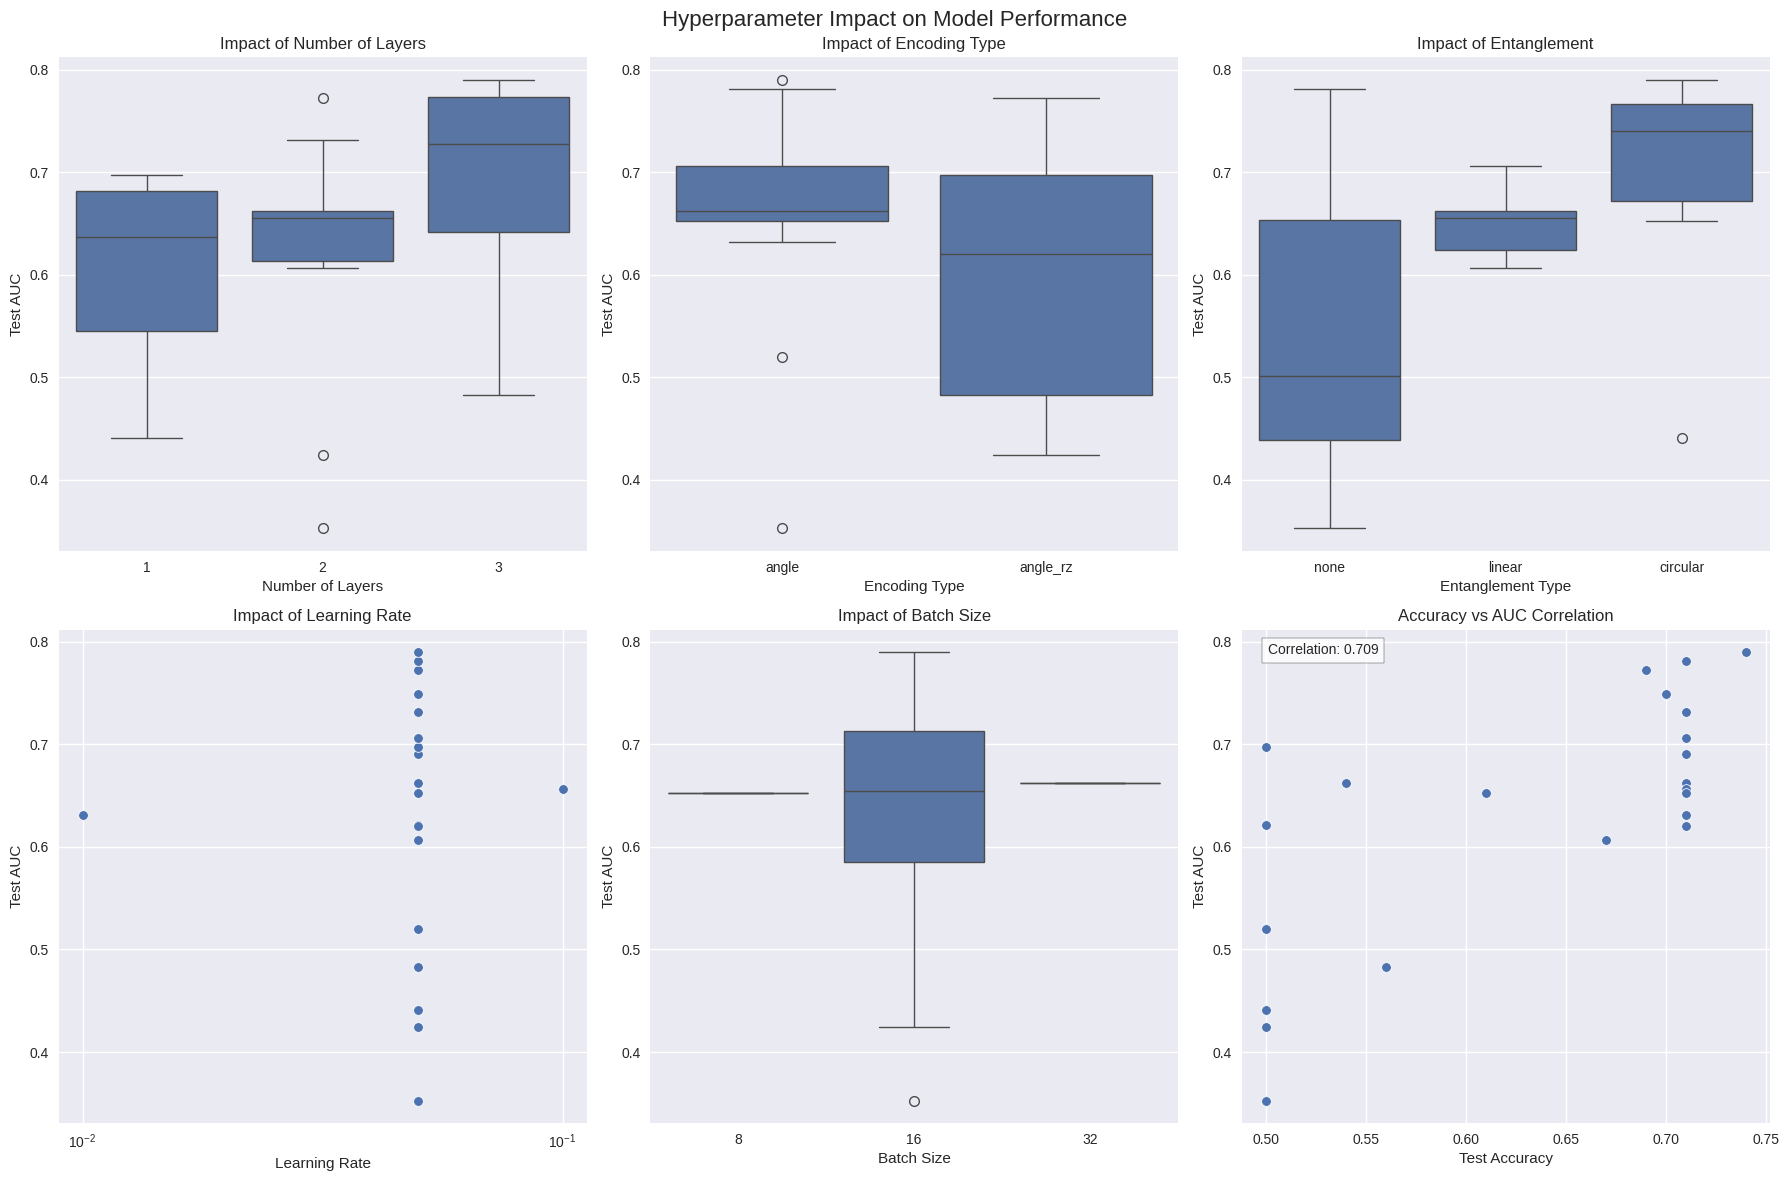

In [17]:
run_hyperparameter_tuning()

In [19]:
run_single_experiment('best')

Running QGAN Classifier with 'best' configuration

Configuration:
  n_qubits: 5
  n_layers: 3
  encoding_type: angle_rz
  entanglement: circular
  learning_rate: 0.05
  batch_size: 16
  epochs: 100
  validation_split: 0.2
  early_stopping_patience: 15

Experiment: run_best
Training samples: 80
Validation samples: 20
Test samples: 100
Circuit Configuration:
  - Qubits: 5
  - Encoding: angle_rz
  - Variational Layers: 3
  - Entanglement: circular
  - Data parameters: 5
  - Trainable parameters: 30

Training...
Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - accuracy: 0.5125 - loss: 0.7102 - val_accuracy: 0.4500 - val_loss: 0.7076
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.5375 - loss: 0.6819 - val_accuracy: 0.8000 - val_loss: 0.6852
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.5750 - loss: 0.6875 - val_accuracy: 0.6000 - val_loss: 0.6792
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.5500 - loss: 0.6834 - val_accuracy: 0.75

In [20]:
run_single_experiment('deep')

Running QGAN Classifier with 'deep' configuration

Configuration:
  n_qubits: 5
  n_layers: 3
  encoding_type: angle_rz
  entanglement: circular
  learning_rate: 0.01
  batch_size: 8
  epochs: 150
  validation_split: 0.2
  early_stopping_patience: 15

Experiment: run_deep
Training samples: 80
Validation samples: 20
Test samples: 100
Circuit Configuration:
  - Qubits: 5
  - Encoding: angle_rz
  - Variational Layers: 3
  - Entanglement: circular
  - Data parameters: 5
  - Trainable parameters: 30

Training...
Epoch 1/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5000 - loss: 0.7072 - val_accuracy: 0.5000 - val_loss: 0.6908
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5000 - loss: 0.6974 - val_accuracy: 0.6000 - val_loss: 0.6898
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5625 - loss: 0.6929 - val_accuracy: 0.8000 - val_loss: 0.6901
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5000 - loss: 0.6924 - val_accuracy: 0

## Inference

In [21]:
import sys
import os
import json
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

In [23]:
def run_inference(data_path: str, config: QGANConfig = None):
    """Run inference on test data and produce detailed evaluation."""

    print("="*70)
    print("QGAN HEP CLASSIFIER - INFERENCE & EVALUATION")
    print("="*70)

    # Default optimized configuration
    if config is None:
        config = QGANConfig(
            n_layers=3,
            encoding_type='angle',
            entanglement='circular',
            learning_rate=0.05,
            batch_size=16,
            epochs=100,
            early_stopping_patience=20
        )

    # Load data
    print("\n[1] Loading data...")
    loader = HEPDataLoader(data_path)
    X_train, y_train, X_test, y_test = loader.load()

    print(f"    Training samples: {len(y_train)}")
    print(f"    Test samples: {len(y_test)}")
    print(f"    Features per sample: {X_train.shape[1]}")

    # Split training data for validation
    n_val = int(len(y_train) * config.validation_split)
    X_val, y_val = X_train[:n_val], y_train[:n_val]
    X_train_split, y_train_split = X_train[n_val:], y_train[n_val:]

    # Build and train model
    print("\n[2] Building quantum classifier...")
    classifier = QGANClassifier(config)
    classifier.circuit_builder.print_circuit_info()

    print("\n[3] Training model...")
    history = classifier.train(X_train_split, y_train_split, X_val, y_val, verbose=1)

    # Evaluate
    print("\n[4] Running inference on test set...")
    test_results = classifier.evaluate(X_test, y_test)
    train_results = classifier.evaluate(X_train_split, y_train_split)

    # Get predictions for detailed analysis
    predictions = test_results['predictions']
    y_pred = (predictions > 0.5).astype(int)

    # Print results
    print("\n" + "="*70)
    print("EVALUATION RESULTS")
    print("="*70)

    print(f"\n### Performance Metrics ###")
    print(f"  Test Accuracy:  {test_results['accuracy']:.4f}")
    print(f"  Test AUC:       {test_results['auc']:.4f}")
    print(f"  Train Accuracy: {train_results['accuracy']:.4f}")
    print(f"  Train AUC:      {train_results['auc']:.4f}")

    print(f"\n### Classification Report ###")
    print(classification_report(y_test, y_pred, target_names=['Background', 'Signal']))

    print(f"\n### Confusion Matrix ###")
    cm = confusion_matrix(y_test, y_pred)
    print(f"  True Background (predicted Background): {cm[0,0]}")
    print(f"  True Background (predicted Signal):     {cm[0,1]}")
    print(f"  True Signal (predicted Background):     {cm[1,0]}")
    print(f"  True Signal (predicted Signal):         {cm[1,1]}")

    # Physics interpretation
    print(f"\n### Physics Interpretation ###")
    signal_efficiency = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
    background_rejection = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
    print(f"  Signal Efficiency (Recall):     {signal_efficiency:.4f}")
    print(f"  Background Rejection:           {background_rejection:.4f}")

    # Save results
    results = {
        'config': config.to_dict(),
        'test_accuracy': test_results['accuracy'],
        'test_auc': test_results['auc'],
        'train_accuracy': train_results['accuracy'],
        'train_auc': train_results['auc'],
        'signal_efficiency': signal_efficiency,
        'background_rejection': background_rejection,
        'epochs_trained': len(history.history['loss']),
        'confusion_matrix': cm.tolist()
    }

    os.makedirs('results', exist_ok=True)
    with open('results/inference_results.json', 'w') as f:
        json.dump(results, f, indent=2)

    print(f"\n[5] Results saved to results/inference_results.json")
    print("="*70)

    return results

In [24]:
if __name__ == "__main__":
  config = QGANConfig(
        n_layers=3,
        encoding_type='angle',
        entanglement='circular',
        learning_rate=0.05,
        batch_size=16,
        epochs=100,
        early_stopping_patience=20
    )
  run_inference('QIS_EXAM_200Events.npz', config)


QGAN HEP CLASSIFIER - INFERENCE & EVALUATION

[1] Loading data...
    Training samples: 100
    Test samples: 100
    Features per sample: 5

[2] Building quantum classifier...
Circuit Configuration:
  - Qubits: 5
  - Encoding: angle
  - Variational Layers: 3
  - Entanglement: circular
  - Data parameters: 5
  - Trainable parameters: 30

[3] Training model...
Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 281ms/step - accuracy: 0.4625 - loss: 0.7056 - val_accuracy: 0.5500 - val_loss: 0.6933
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4125 - loss: 0.6945 - val_accuracy: 0.4500 - val_loss: 0.6988
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5125 - loss: 0.6893 - val_accuracy: 0.4500 - val_loss: 0.6945
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5125 - loss: 0.6895 - val_accuracy: 0.4500 - val_loss: 0.6870
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5125 - loss: 0.6784 - val_accuracy: 0.4500 - val_loss: 0.6622
Epoch 6